--- STANDARD ROUND ROBIN ---
P2 (I/O) finished at 17 mins.
P3 (CPU) finished at 21 mins.
P1 (CPU) finished at 23 mins.

--- AI SMART SCHEDULER (With I/O Priority) ---
[AI] P2 (I/O) finished at 5 mins.
[AI] P3 (CPU) finished at 21 mins.
[AI] P1 (CPU) finished at 23 mins.

Standard Avg Turnaround Time: 20.33 mins
AI Smart Avg Turnaround Time: 16.33 mins


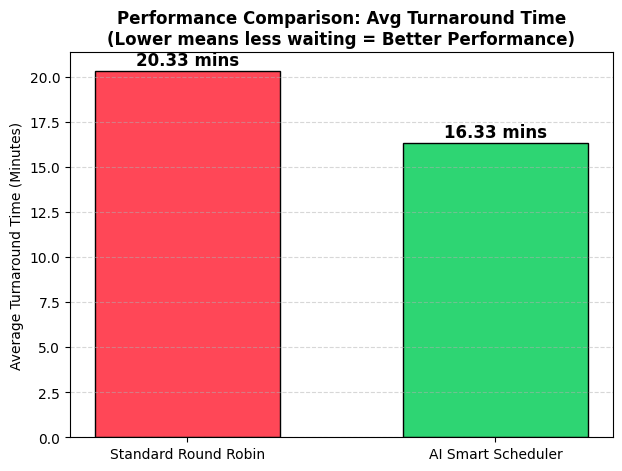

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# ==========================================
# 1. TRAIN AI MODEL
# ==========================================
ai_model = DecisionTreeClassifier()
# features: [time needed, I/O requests], labels: 0 (I/O-bound) or 1 (CPU-bound)
ai_model.fit([[2, 10], [3, 8], [15, 1], [20, 0], [5, 6], [12, 2]], [0, 0, 1, 1, 0, 1])

processes = ["P1 (CPU)", "P2 (I/O)", "P3 (CPU)"]
process_features = [[10, 1], [5, 10], [8, 2]]

# ==========================================
# 2. STANDARD ROUND ROBIN
# ==========================================
def run_standard_rr():
    print("--- STANDARD ROUND ROBIN ---")
    time_needed = [10, 5, 8]
    time_limit = 4
    current_time = 0
    turnaround_times = [0, 0, 0]

    for round_number in range(4):
        for i in range(3):
            time_left = time_needed[i]
            if time_left > 0:
                if time_left > time_limit:
                    current_time += time_limit
                    time_needed[i] -= time_limit
                else:
                    current_time += time_left
                    time_needed[i] = 0
                    turnaround_times[i] = current_time
                    print(f"{processes[i]} finished at {current_time} mins.")

    return sum(turnaround_times) / 3

# ==========================================
# 3.  AI-BASED SMART SCHEDULER
# ==========================================
def run_ai_smart_rr():
    print("\n--- AI SMART SCHEDULER (With I/O Priority) ---")
    time_needed = [10, 5, 8]
    current_time = 0
    turnaround_times = [0, 0, 0]

    # --- reorder the Queue ---
    #  AI predicts the type. If it's I/O (0), we push it to the FRONT of the line
    smart_order = []
    for i in range(3):
        if ai_model.predict([process_features[i]])[0] == 0:
            smart_order.insert(0, i) # Push to front
        else:
            smart_order.append(i)    # Push to back

    # now run the processes
    while sum(time_needed) > 0:
        for i in smart_order:
            if time_needed[i] > 0:

                # dynamic limits: CPU gets 8 mins, I/O gets 5 mins
                limit = 8 if ai_model.predict([process_features[i]])[0] == 1 else 5

                spent_time = min(time_needed[i], limit)
                current_time += spent_time
                time_needed[i] -= spent_time

                if time_needed[i] == 0:
                    turnaround_times[i] = current_time
                    print(f"[AI] {processes[i]} finished at {current_time} mins.")

    return sum(turnaround_times) / 3

# ==========================================
# 4.SIMULATIONS & VISUALS
# ==========================================
standard_tat = run_standard_rr()
ai_tat = run_ai_smart_rr()

print(f"\nStandard Avg Turnaround Time: {standard_tat:.2f} mins")
print(f"AI Smart Avg Turnaround Time: {ai_tat:.2f} mins")

# visual comparison
labels = ['Standard Round Robin', 'AI Smart Scheduler']
values = [standard_tat, ai_tat]

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=['#ff4757', '#2ed573'], edgecolor='black', width=0.6)
plt.title('Performance Comparison: Avg Turnaround Time\n(Lower means less waiting = Better Performance)', fontweight='bold')
plt.ylabel('Average Turnaround Time (Minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# add the final score numbers to the graph
for i, v in enumerate(values):
    plt.text(i, v + 0.3, f"{v:.2f} mins", ha='center', fontweight='bold', fontsize=12)

plt.show()